# 앙상블 학습 ① Voting · Bagging · Random Forest — V3.2.2

**오늘의 문제**: 여러 모델을 합치면 언제 더 안정적이고, 언제 그렇지 않을까?

**오늘의 목표**
1. 작은 데이터 변화에 따른 단일 Tree의 경계 흔들림을 직접 관찰한다.
2. Voting 반례를 먼저 보고 disagreement와 error overlap으로 이유를 해석한다.
3. Bagging → OOB → Random Forest를 질문과 Evidence의 순서로 연결한다.
4. Random Forest와 ExtraTrees를 `DEVELOPMENT_POOL`에서 선택한 뒤 `FINAL_HOLDOUT`을 한 번만 연다.


---
## 결정 트리 복습 → 오늘의 관찰 문제

| 장점 | 오늘 확인할 질문 |
|---|---|
| 사람이 규칙을 읽을 수 있다 | 학습 표본이 조금 바뀌면 경계도 많이 바뀔까? |
| 스케일링이 필수는 아니다 | 여러 Tree의 표를 모으면 흔들림은 어떻게 달라질까? |



## Question → Prediction | 트리는 왜 불안정할까?

데이터에서 일부 표본만 달라져도 단일 Tree의 결정 경계는 얼마나 바뀔까?

**먼저 예상해 보기**
- 단일 Tree와 여러 Tree를 평균낸 것(Bagging) 중 어느 쪽 경계가 seed 변화에 더 흔들릴까?



In [25]:
# Run — bootstrap 표본을 바꿨을 때 Tree와 Bagging 경계의 흔들림 비교
print("관찰 순서: ① 위쪽 Tree 3개 → ② 아래쪽 Bagging 3개 → ③ 마지막 불일치율 표")
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

X_instability, y_instability = make_classification(
    n_samples=260, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=0.9, flip_y=0.08, random_state=42
)

x0 = np.linspace(X_instability[:, 0].min() - 0.7, X_instability[:, 0].max() + 0.7, 130)
x1 = np.linspace(X_instability[:, 1].min() - 0.7, X_instability[:, 1].max() + 0.7, 130)
xx, yy = np.meshgrid(x0, x1)
grid_points = np.c_[xx.ravel(), yy.ravel()]
sample_seeds = [3, 17, 91]
tree_boundaries, bag_boundaries = [], []

fig = make_subplots(rows=2, cols=3, subplot_titles=[
    "Tree · sample 1", "Tree · sample 2", "Tree · sample 3",
    "Bagging · sample 1", "Bagging · sample 2", "Bagging · sample 3"
])

for col, seed in enumerate(sample_seeds, start=1):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_instability), size=len(X_instability), replace=True)
    X_boot, y_boot = X_instability[idx], y_instability[idx]

    tree_demo = DecisionTreeClassifier(random_state=seed).fit(X_boot, y_boot)
    bag_demo = BaggingClassifier(
        estimator=DecisionTreeClassifier(), n_estimators=80,
        bootstrap=True, random_state=seed, n_jobs=-1
    ).fit(X_boot, y_boot)

    for row, model, store in [(1, tree_demo, tree_boundaries), (2, bag_demo, bag_boundaries)]:
        z = model.predict(grid_points).reshape(xx.shape)
        store.append(z.ravel())
        fig.add_trace(go.Contour(
            x=x0, y=x1, z=z, showscale=False, opacity=0.45,
            colorscale=[[0, "#244B7A"], [1, "#9A3D4A"]],
            contours=dict(coloring="fill"), line_width=0
        ), row=row, col=col)
        fig.add_trace(go.Scatter(
            x=X_boot[:, 0], y=X_boot[:, 1], mode="markers", showlegend=False,
            marker=dict(color=y_boot, colorscale="RdBu", size=4, line=dict(width=0.2, color="white"))
        ), row=row, col=col)

fig.update_layout(height=650, width=1050, template="plotly_dark",
                  title="같은 생성 규칙, 다른 bootstrap sample — 결정 경계 비교")
fig.show()

def mean_pair_disagreement(boundaries):
    pairs = []
    for i in range(len(boundaries)):
        for j in range(i + 1, len(boundaries)):
            pairs.append(np.mean(boundaries[i] != boundaries[j]))
    return np.mean(pairs)

instability_evidence = pd.DataFrame({
    "Model": ["Single Tree", "Bagging"],
    "Mean boundary disagreement": [
        mean_pair_disagreement(tree_boundaries),
        mean_pair_disagreement(bag_boundaries)
    ]
})
display(instability_evidence.style.format({"Mean boundary disagreement": "{:.3f}"}))


관찰 순서: ① 위쪽 Tree 3개 → ② 아래쪽 Bagging 3개 → ③ 마지막 불일치율 표


,Model,Mean boundary disagreement
0,Single Tree,0.108
1,Bagging,0.061


### Evidence → Interpretation → Better Question

- **Evidence**: 표의 경계 불일치율이 클수록 표본 변화에 더 민감하다.
- **Interpretation**: 이 실행에서는 단일 Tree가 얼마나 흔들렸고, Bagging은 그 흔들림을 얼마나 줄였는가?
- **Better Question**: 서로 다른 종류의 모델을 합치는 Voting도 언제나 좋아질까?


---
## w — 앙상블 전체 지도

> Core에서는 이 묶음을 건너뛰고 Voting 실험으로 바로 간다. 개념 이름을 한 번에 복습할 때만 사용한다.

- **Voting**: 서로 다른 모델의 예측을 결합한다.
- **Bagging**: 같은 종류의 모델에 서로 다른 표본을 보여 준다.
- **Random Forest**: Bagging 다음에 등장할 질문의 답이며, Core에서 문제를 먼저 본 뒤 reveal한다.
- **Boosting**: Part 2에서 다룰 순차 앙상블이다.


## w — Bias vs Variance

Core에서 필요한 문장은 하나다: **Variance가 높으면 학습 표본이 조금 바뀔 때 예측이 크게 흔들릴 수 있다.**

- **Bias (편향)**: 모델이 중요한 패턴을 충분히 학습하지 못하는 경향
- **Variance (분산)**: 학습 데이터 변화에 예측이 민감하게 달라지는 경향
- 아래 그림·곡선·표는 복습이 필요할 때만 선택적으로 본다.


### w 이미지 A — Bias vs Variance
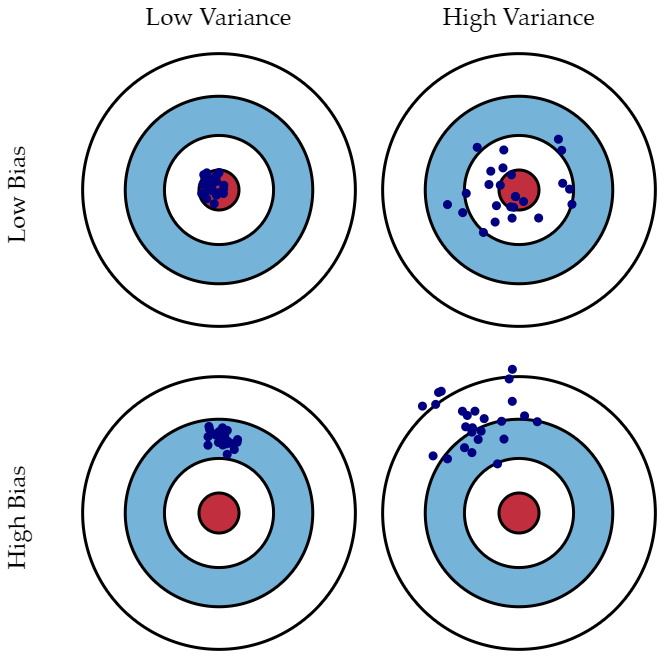

- 출처: http://scott.fortmann-roe.com


### w 코드 — Bias vs Variance 곡선 시각화


In [26]:
import numpy as np
import plotly.graph_objects as go

complexity = np.linspace(0, 10, 100)

bias2 = (10 - complexity) ** 2 / 10
variance = (complexity) ** 2 / 10
error = bias2 + variance

fig = go.Figure()
fig.add_trace(go.Scatter(x=complexity, y=bias2, mode="lines", name="Bias² (편향 제곱)", line=dict(color="cyan", width=3)))
fig.add_trace(
    go.Scatter(x=complexity, y=variance, mode="lines", name="Variance (분산)", line=dict(color="magenta", width=3)))
fig.add_trace(go.Scatter(x=complexity, y=error, mode="lines", name="Total Error (총 오차)",
                         line=dict(color="yellow", width=3, dash="dot")))
fig.add_vline(x=5, line=dict(color="green", width=2, dash="dash"), annotation_text="균형점",
              annotation_position="top right")
fig.update_layout(title="Bias vs Variance Trade-off", xaxis_title="모델 복잡도", yaxis_title="오차 (Error)",
                  template="plotly_dark")
fig.show()

### w 표

| **구분** | **Bias** | **Variance** | **상태** | **예시** |
|---|---:|---:|---|---|
| Low Bias · Low Var | ↓ | ↓ | 이상적 | 중심 근처에 모인 점 |
| Low Bias · High Var | ↓ | ↑ | 과적합 | 중심 주변 흩어짐 |
| High Bias · Low Var | ↑ | ↓ | 과소적합 | 한쪽에 몰림 |
| High Bias · High Var | ↑ | ↑ | 둘 다 큼 | 멀리 흩어짐 |

Core에서는 “Tree가 표본 변화에 흔들리는가?”라는 관찰로 돌아간다.


### w 마무리

- Bagging은 여러 모델의 평균으로 흔들림을 줄이려는 방법이다.
- Boosting은 앞 단계의 약점을 다음 단계 학습 신호로 쓰며 Part 2에서 다룬다.
- Part 1 Core에서는 정의 암기보다 Voting 반례와 동일한 평가 계약의 Evidence를 우선한다.


## 2) Question → Prediction | Voting

서로 다른 모델의 예측을 합치면 가장 좋은 단일 모델보다도 좋아질까?

**먼저 예상해 보기**
- Hard Voting과 Soft Voting 중 어느 쪽이 더 높을까?
- 세 모델의 실수가 비슷하게 겹친다면 결과는 어떻게 될까?

**Run에서 확인할 것**
- **Hard Voting**: 라벨 다수결
- **Soft Voting**: 예측 확률 평균
- Soft Voting은 확률 품질과 모델 다양성에 따라 결과가 달라지며 항상 우월하지 않다.


### Hard Voting vs Soft Voting — 방식 비교 뒤 질문
![Hard Voting vs Soft Voting](assets/Hard_vs_Soft_Voting.png)

> Soft Voting은 확률·확신도를 반영한다. **이번에는 항상 유리할까?** 답은 바로 뒤의 동일 `DEVELOPMENT_POOL` CV Evidence로 확인한다.


### Optional Detail — Soft Voting과 확률 품질
![Soft Voting의 함정 - 확률 품질](assets/Soft_Voting_확률품질.png)

> Soft Voting은 확률 정보를 이용하는 방식이다. 확률 품질이 중요하지만, 보정 여부만으로 성능이 결정되거나 Hard Voting보다 항상 우수해지는 것은 아니다.


### Optional Detail — 신뢰도 보정 전략
![신뢰도 보정 전략](assets/신뢰도_보정_전략.png)

보정은 별도의 development Evidence로 효과를 확인해야 하며, 이 Core Voting 반례의 결과를 바꾸기 위한 사후 조치가 아니다.


## Wine

In [27]:
import numpy as np, pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X_all, y_all = wine.data, wine.target
feature_names = wine.feature_names
target_names = wine.target_names

# 평가 계약: 먼저 FINAL_HOLDOUT을 잠그고, 모든 선택은 DEVELOPMENT_POOL 안에서 수행
X_development, X_final_holdout, y_development, y_final_holdout = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# 기존 심화 셀과의 호환용 이름. 둘 다 development 데이터이며 final holdout이 아님.
X_train, y_train = X_development, y_development

FINAL_HOLDOUT_ACCESS_COUNT = 0
FINAL_MODEL_FROZEN = False

def open_final_holdout_once():
    global FINAL_HOLDOUT_ACCESS_COUNT
    if not FINAL_MODEL_FROZEN:
        raise RuntimeError("모델과 하이퍼파라미터 선택을 먼저 완료한 뒤 FINAL_HOLDOUT을 여세요.")
    if FINAL_HOLDOUT_ACCESS_COUNT != 0:
        raise RuntimeError(
            "FINAL_HOLDOUT은 이미 한 번 열었습니다. 다시 시작하려면 "
            "Kernel Restart 후 처음부터 실행하세요."
        )
    FINAL_HOLDOUT_ACCESS_COUNT += 1
    return X_final_holdout, y_final_holdout

print("DEVELOPMENT_POOL:", X_development.shape)
print("FINAL_HOLDOUT (locked):", X_final_holdout.shape)


DEVELOPMENT_POOL: (142, 13)
FINAL_HOLDOUT (locked): (36, 13)


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

log_clf = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=5000, random_state=42))])

knn_clf = Pipeline([("scaler", StandardScaler()),
                    ("clf", KNeighborsClassifier(n_neighbors=7))])

dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [29]:
from sklearn.ensemble import VotingClassifier

voting_hard = VotingClassifier(
    estimators=[("lr", log_clf), ("knn", knn_clf), ("dt", dt_clf)], voting="hard"
)
voting_soft = VotingClassifier(
    estimators=[("lr", log_clf), ("knn", knn_clf), ("dt", dt_clf)], voting="soft"
)


In [30]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "Logistic": log_clf,
    "KNN": knn_clf,
    "Decision Tree": dt_clf,
    "Hard Voting": voting_hard,
    "Soft Voting": voting_soft,
}

voting_rows = []
oof_predictions = {}
for name, model in models.items():
    scores = cross_val_score(model, X_development, y_development, cv=cv, scoring="accuracy", n_jobs=-1)
    oof = cross_val_predict(model, X_development, y_development, cv=cv, n_jobs=-1)
    oof_predictions[name] = oof
    voting_rows.append({"Model": name, "CV mean": scores.mean(), "CV std": scores.std()})

voting_cv_evidence = pd.DataFrame(voting_rows).sort_values("CV mean", ascending=False)
print("관찰 순서: ① CV 1등 → ② Hard Voting → ③ Soft Voting (mean 다음 std)")
display(voting_cv_evidence.style.format({"CV mean": "{:.3f}", "CV std": "{:.3f}"}))


관찰 순서: ① CV 1등 → ② Hard Voting → ③ Soft Voting (mean 다음 std)


,Model,CV mean,CV std
0,Logistic,0.979,0.028
3,Hard Voting,0.972,0.040
4,Soft Voting,0.965,0.031
1,KNN,0.958,0.041
2,Decision Tree,0.902,0.059


### Voting Evidence 뒤 PAUSE

**[PAUSE 20~30초 — 다음 코드를 아직 실행하지 않는다]**

1. 표에서 1등 모델과 CV mean을 먼저 찾는다.
2. Hard Voting과 Soft Voting이 그 값을 넘었는지 확인한다.
3. 결론은 “Voting은 나쁘다”가 아니라 **“이 조합에서는 최고 단일 모델보다 개선되지 않았다”**로 제한한다.

**질문:** 합쳤는데 개선되지 않은 이유를 알아보려면 모델들이 얼마나 다르게 예측하는지만 보면 충분할까?


In [31]:
# Evidence — 모델 간 disagreement와 error overlap
base_names = ["Logistic", "KNN", "Decision Tree"]
pair_rows = []
for i, left in enumerate(base_names):
    for right in base_names[i + 1:]:
        left_pred, right_pred = oof_predictions[left], oof_predictions[right]
        left_error = left_pred != y_development
        right_error = right_pred != y_development
        union = np.logical_or(left_error, right_error).sum()
        pair_rows.append({
            "Pair": f"{left} vs {right}",
            "Prediction disagreement": np.mean(left_pred != right_pred),
            "Both wrong": np.mean(left_error & right_error),
            "Error overlap (Jaccard)": (
                np.logical_and(left_error, right_error).sum() / union
            ) if union else 0.0,
        })

disagreement_evidence = pd.DataFrame(pair_rows)

print("관찰 1/2: Prediction disagreement만 먼저 봅니다.")
display(disagreement_evidence[["Pair", "Prediction disagreement"]].style.format({
    "Prediction disagreement": "{:.3f}",
}))
print("PAUSE 질문: 예측이 많이 다르면 곧바로 좋은 조합일까요?")

print("관찰 2/2: 이제 Both wrong과 error overlap을 reveal합니다.")
print("Jaccard 수식 계산은 Optional이며, Core에서는 오류가 함께 겹치는 정도로 읽습니다.")
display(disagreement_evidence.style.format({
    "Prediction disagreement": "{:.3f}",
    "Both wrong": "{:.3f}",
    "Error overlap (Jaccard)": "{:.3f}",
}))

comparison = voting_cv_evidence.set_index("Model")["CV mean"]
best_single = comparison.loc[["Logistic", "KNN", "Decision Tree"]].max()
best_voting = comparison.loc[["Hard Voting", "Soft Voting"]].max()
print(f"Best single CV: {best_single:.3f}")
print(f"Best voting CV: {best_voting:.3f}")
print(
    "Evidence:",
    "이 조합에서 Voting이 더 높았다"
    if best_voting > best_single
    else "이 조합에서 Voting이 최강 단일 모델을 넘지 못했다",
)


관찰 1/2: Prediction disagreement만 먼저 봅니다.


,Pair,Prediction disagreement
0,Logistic vs KNN,0.028
1,Logistic vs Decision Tree,0.106
2,KNN vs Decision Tree,0.113


PAUSE 질문: 예측이 많이 다르면 곧바로 좋은 조합일까요?
관찰 2/2: 이제 Both wrong과 error overlap을 reveal합니다.
Jaccard 수식 계산은 Optional이며, Core에서는 오류가 함께 겹치는 정도로 읽습니다.


,Pair,Prediction disagreement,Both wrong,Error overlap (Jaccard)
0,Logistic vs KNN,0.028,0.021,0.500
1,Logistic vs Decision Tree,0.106,0.007,0.062
2,KNN vs Decision Tree,0.113,0.014,0.111


Best single CV: 0.979
Best voting CV: 0.972
Evidence: 이 조합에서 Voting이 최강 단일 모델을 넘지 못했다


### Reveal — 앙상블 다양성 (Diversity)
![앙상블 다양성 (Diversity)](assets/앙상블_다양성_Diversity.png)

예측이 다르다는 사실만으로 좋은 앙상블이 되지는 않는다. 구성원의 기본 품질과 **오류가 어떻게 겹치는지**를 함께 본다.


### Reveal — 모델 오류가 함께 움직일 때
![모델 오류가 함께 움직일 때](assets/앙상블_독립성_Independence.png)

여기서 완전한 독립을 가정하지 않는다. 모델들이 비슷하게 움직일수록 평균 안정화 효과가 줄 수 있다는 직관을 보고, 실제로는 disagreement·error overlap과 development Evidence를 확인한다.


### Interpretation → Better Question

- Logistic `0.979`, Hard Voting `0.972`, Soft Voting `0.965`라면 **이 조합에서 개선되지 않았다**고만 말한다.
- disagreement가 크다는 사실만으로 충분하지 않다. Both wrong과 error overlap, 각 구성원의 기본 성능을 함께 본다.
- 점수가 예상과 달라도 seed를 바꾸거나 반례를 숨기지 않는다.
- **Better Question**: 서로 다른 모델을 고르는 대신, 같은 Tree에 서로 다른 표본을 보여 주어 흔들림을 평균내면 어떨까?

→ 다음은 **Bagging**이다.


## 3) Bagging → OOB

- Bagging은 같은 종류의 모델을 서로 다른 bootstrap 표본에 학습해 예측을 결합한다.
- 표본 변화에 민감한 Tree의 흔들림을 평균으로 줄이는 것이 설계 의도이며, 실제 효과는 Evidence로 확인한다.

### OOB 역할을 먼저 제한하기

**OOB는 bootstrap 과정에서 생기는 `DEVELOPMENT_POOL` 내부의 보조 성능 추정치다.**

- `FINAL_HOLDOUT`이 아니다.
- 모든 상황에서 CV를 대체한다는 규칙도 아니다.

**[PAUSE] 질문:** 한 샘플을 평가할 때, 그 샘플을 학습에서 본 Tree와 보지 않은 Tree 중 어느 쪽의 표만 받아야 더 정직할까?


### OOB의 탄생 - Bagging Process
![OOB의 탄생 - Bagging Process](assets/OOB_탄생_Bagging.png)

### OOB 평가 프로세스
![OOB 평가 프로세스](assets/OOB_평가_프로세스.png)

In [32]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

bag_wine = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300, bootstrap=True, oob_score=True,
    n_jobs=-1, random_state=42
)
bag_scores = cross_val_score(
    bag_wine, X_development, y_development, cv=cv, scoring="accuracy", n_jobs=-1
)
bag_wine.fit(X_development, y_development)

print("관찰 순서: ① Development CV mean±std → ② OOB estimate → ③ holdout 잠금 상태")
print(f"Development CV: {bag_scores.mean():.3f} ± {bag_scores.std():.3f}")
print(f"OOB estimate  : {bag_wine.oob_score_:.3f}")
print("FINAL_HOLDOUT access:", FINAL_HOLDOUT_ACCESS_COUNT)
print("질문: CV와 OOB 값이 같아도 같은 평가법이라고 말할 수 있을까요?")


관찰 순서: ① Development CV mean±std → ② OOB estimate → ③ holdout 잠금 상태
Development CV: 0.944 ± 0.041
OOB estimate  : 0.944
FINAL_HOLDOUT access: 0
질문: CV와 OOB 값이 같아도 같은 평가법이라고 말할 수 있을까요?


## OOB Evidence 해석

- OOB는 bootstrap에서 해당 샘플을 학습에 쓰지 않은 Tree들의 표를 모은 내부 추정치다.
- 오늘 `CV 0.944`와 `OOB 0.944`가 같더라도 두 평가법이 같다는 뜻이 아니다.
- OOB는 `FINAL_HOLDOUT`이 아니며, 별도 validation 또는 CV를 모든 상황에서 없애는 보편 규칙도 아니다.
- 숫자 하나보다 평가 역할과 생성 과정을 먼저 구분한다.


## Question → Prediction | Bagging 다음에는 무엇을 바꿀까?

bootstrap 표본이 달라도 아주 강한 feature 때문에 Tree들이 계속 비슷한 첫 질문을 고를 수 있다.

**질문:** Tree들이 너무 비슷하면 평균 효과는 어떻게 될까? 데이터의 **행(row)** 말고 무엇을 다르게 보여줄 수 있을까?

**[PAUSE 20초]** 답을 한 문장으로 적은 뒤 다음 셀에서 reveal한다.


### Reveal — Random Forest

- **Random Forest = Bagging(여러 Tree) + feature randomness(`max_features`)**
- 목적은 Tree들이 덜 닮게 만들어 평균할 때 상관된 흔들림을 줄이는 것이다.
- 이는 성능 보장이 아니다. Bagging과 같은 `DEVELOPMENT_POOL` Evidence로 평균과 fold 표준편차를 비교한다.


### Random Forest 병렬적 다양성
![Random Forest 병렬적 다양성](assets/Random_Forest_병렬적다양성.png)

> 그림은 설계 의도를 설명한다. Bagging보다 항상 높은 성능을 보장하지 않으며, 이 노트북에서는 development Evidence로 확인한다.


### Bootstrap과 Feature Randomness — 두 원천을 분리해 보기
![Bootstrap과 Feature Randomness](assets/Bootstrap_Feature_Randomness.png)

행(row) 무작위화와 feature 후보 무작위화는 서로 다른 다양성 원천이다. Tree들이 실제로 덜 닮고 CV mean·std가 달라지는지는 development Evidence로 확인한다.


### 왜 `max_features`가 필요한가?

- 강한 feature가 계속 먼저 보이면 bootstrap 표본이 달라도 Tree 규칙이 닮을 수 있다.
- RF는 분기마다 고려할 feature를 제한해 서로 다른 관점을 만들려 한다.
- 상관과 variance가 줄어들 수 있지만, 정보 손실이나 bias 증가도 가능하므로 결과는 보장되지 않는다.


### 핵심 하이퍼파라미터
| 항목 | 설명 | WHY |
|---|---|---|
| `n_estimators` | 트리 개수 | 많을수록 평균 효과가 커질 수 있지만 시간·메모리 비용도 증가 |
| `max_features` | 분기마다 고려할 피처 수 | 작을수록 다양성이 커질 수 있으나 너무 작으면 정보 손실 가능 |
| `max_depth`/`min_samples_leaf` | 트리 복잡도 제어 | 일반화 성능은 `DEVELOPMENT_POOL`에서 확인 |
| `oob_score=True` | Out-of-Bag 내부 추정 | bootstrap에서 빠진 표본으로 성능을 추정 |
| `n_jobs=-1` | 병렬 학습 | 사용 가능한 코어를 활용해 학습 시간 단축 가능 |

> OOB와 CV는 성격이 다르다. 모델·하이퍼파라미터 선택은 `DEVELOPMENT_POOL`에서 끝내고 공식 평가는 `FINAL_HOLDOUT`에서 한 번만 수행한다.


### Bias–Variance 관점의 가설

- 단일 Tree는 표본 변화에 민감할 수 있다.
- Bagging은 여러 Tree의 평균으로 그 흔들림을 줄이려 한다.
- Random Forest는 feature randomness까지 더해 Tree 간 상관을 낮추려 한다.

> 어디까지나 가설과 설계 의도다. 바로 뒤 동일 CV 비교의 mean과 std로 확인한다.


### Random Forest의 설계 의도 — 흔들림을 줄일 수 있을까?
![Random Forest의 설계 의도](assets/Random_Forest_Variance_감소.png)

> 그림은 일반적 설계 의도다. 보편적 분산 감소나 성능 향상을 선언하지 않으며, 같은 `DEVELOPMENT_POOL`의 Single Tree·Bagging·RF CV mean·std가 판단 근거다.


---
## Optional Quick Demo — Single Tree vs Bagging

셀 4에서 경계 흔들림을 이미 관찰했다. 시간이 있을 때만 그림 한 쌍과 demo CV를 빠르게 확인한다.

> Core climax는 뒤의 Wine `Single Tree vs Bagging vs Random Forest` 동일 CV 비교다.


In [33]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine, make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.inspection import permutation_importance
import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go

In [34]:
X2, y2 = make_classification(
    n_samples=500, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.0, random_state=42
)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X2, y2)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=100, max_samples=0.8, bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X2, y2)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300),
    np.linspace(X2[:, 1].min() - 1, X2[:, 1].max() + 1, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_single = tree_single.predict(grid).reshape(xx.shape)
Z_bag = bagging.predict(grid).reshape(xx.shape)

fig1 = go.Figure(data=[go.Contour(x=xx[0], y=yy[:, 0], z=Z_single, showscale=False, opacity=0.3)])
fig1.add_scatter(x=X2[:, 0], y=X2[:, 1], mode="markers",
                 marker=dict(size=6, color=y2), showlegend=False)
fig1.update_layout(title="Decision Boundary — Single Tree",
                   template="plotly_dark", xaxis_title="x1", yaxis_title="x2")
fig1.show()

fig2 = go.Figure(data=[go.Contour(x=xx[0], y=yy[:, 0], z=Z_bag, showscale=False, opacity=0.3)])
fig2.add_scatter(x=X2[:, 0], y=X2[:, 1], mode="markers",
                 marker=dict(size=6, color=y2), showlegend=False)
fig2.update_layout(title="Decision Boundary — Bagging",

                   template="plotly_dark", xaxis_title="x1", yaxis_title="x2")

fig2.show()


In [35]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score

X_demo_train, X_demo_validation, y_demo_train, y_demo_validation = train_test_split(
    X2, y2, test_size=0.3, stratify=y2, random_state=42
)

tree_single = DecisionTreeClassifier(max_depth=None, random_state=42).fit(
    X_demo_train, y_demo_train
)
bagging = BaggingClassifier(
    DecisionTreeClassifier(max_depth=None),
    n_estimators=100, max_samples=0.8, bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X_demo_train, y_demo_train)

print("Single Tree  Demo Validation Acc:", accuracy_score(
    y_demo_validation, tree_single.predict(X_demo_validation)
))
print("Bagging      Demo Validation Acc:", accuracy_score(
    y_demo_validation, bagging.predict(X_demo_validation)
))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tree_cv = cross_val_score(
    DecisionTreeClassifier(max_depth=None, random_state=42),
    X2, y2, cv=cv, scoring="accuracy", n_jobs=-1
)
bag_cv = cross_val_score(
    BaggingClassifier(
        DecisionTreeClassifier(max_depth=None),
        n_estimators=100, max_samples=0.8, bootstrap=True,
        n_jobs=-1, random_state=42
    ),
    X2, y2, cv=cv, scoring="accuracy", n_jobs=-1
)
print(f"Single Tree  Demo CV mean±std: {tree_cv.mean():.3f} ± {tree_cv.std():.3f}")
print(f"Bagging      Demo CV mean±std: {bag_cv.mean():.3f} ± {bag_cv.std():.3f}")


Single Tree  Demo Validation Acc: 0.94
Bagging      Demo Validation Acc: 0.9666666666666667
Single Tree  Demo CV mean±std: 0.944 ± 0.022
Bagging      Demo CV mean±std: 0.952 ± 0.021


### CORE — Wine: Single Tree vs Bagging vs Random Forest

**실행 전 Prediction**
1. CV 평균 순위를 예상한다.
2. fold가 바뀔 때 가장 많이 흔들릴 모델, 즉 std가 가장 클 모델도 고른다.

**[PAUSE 20초]** 평균 순위와 std 순위를 각각 기록한 뒤 실행한다.

이 비교는 `DEVELOPMENT_POOL`만 사용하며 final holdout을 열지 않는다.


In [36]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

core_models = {
    "Single Tree": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=300, bootstrap=True, oob_score=True,
        n_jobs=-1, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_features="sqrt", bootstrap=True, oob_score=True,
        n_jobs=-1, random_state=42
    ),
}

core_rows = []
for name, model in core_models.items():
    scores = cross_val_score(model, X_development, y_development, cv=cv, scoring="accuracy", n_jobs=-1)
    core_rows.append({"Model": name, "CV mean": scores.mean(), "CV std": scores.std()})

core_comparison = pd.DataFrame(core_rows).sort_values("CV mean", ascending=False)
print("관찰 순서: ① CV mean 순위 → ② fold 흔들림(CV std) → ③ 이 Wine 실행으로만 해석")
display(core_comparison.style.format({"CV mean": "{:.3f}", "CV std": "{:.3f}"}))
print("Evidence: 핵심 비교는 DEVELOPMENT_POOL CV만 사용했습니다.")


관찰 순서: ① CV mean 순위 → ② fold 흔들림(CV std) → ③ 이 Wine 실행으로만 해석


,Model,CV mean,CV std
2,Random Forest,0.979,0.028
1,Bagging,0.944,0.041
0,Single Tree,0.902,0.059


Evidence: 핵심 비교는 DEVELOPMENT_POOL CV만 사용했습니다.


---
## Optional Lab A — Feature Importance / Permutation / Collinearity

> Core route에서는 이 묶음을 건너뛰고 **CORE RESUMES — RF vs ExtraTrees family selection**으로 이동한다.

- `DEVELOPMENT_POOL`을 fit → selection → untouched evaluation으로 나눈다.
- Importance는 모델이 사용한 흔적이지 인과관계가 아니다.
- 피처를 고른 selection set으로 성공을 재주장하지 않는다.
- 실제 `accuracy` 평가 계약과 `전체 1.0000 > 선택 0.9722` 반례를 그대로 보존한다.


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import plotly.express as px

# DEVELOPMENT_POOL 내부에서만 세 역할을 분리한다.
# 50% fit / 25% selection / 25% untouched evaluation (반올림에 따라 표본 수는 조금 달라질 수 있음)
X_feature_work, X_feature_evaluate, y_feature_work, y_feature_evaluate = train_test_split(
    X_development, y_development,
    test_size=0.25, stratify=y_development, random_state=42
)
X_feature_fit, X_feature_select, y_feature_fit, y_feature_select = train_test_split(
    X_feature_work, y_feature_work,
    test_size=1/3, stratify=y_feature_work, random_state=43
)

rf_feature_fit = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X_feature_fit, y_feature_fit)

# 피처 순위와 선택 규칙은 selection set만 본다.
feature_perm = permutation_importance(
    rf_feature_fit, X_feature_select, y_feature_select,
    n_repeats=20, scoring="accuracy", n_jobs=-1, random_state=42
)

print("Feature-selection contract:")
print(" fit / selection / untouched evaluation =", len(X_feature_fit), "/", len(X_feature_select), "/", len(X_feature_evaluate))
print(" FINAL_HOLDOUT access:", FINAL_HOLDOUT_ACCESS_COUNT)

importances_impurity = pd.Series(
    rf_feature_fit.feature_importances_, index=wine.feature_names
).sort_values()
fig = px.bar(
    importances_impurity, orientation="h",
    title="Random Forest — Feature Importances (fit subset)", template="plotly_dark"
)
fig.update_layout(xaxis_title="importance", yaxis_title="feature")
fig.show()

importances_perm = pd.Series(
    feature_perm.importances_mean, index=wine.feature_names
).sort_values()
fig = px.bar(
    importances_perm, orientation="h",
    title="Random Forest — Permutation Importances (selection subset only)", template="plotly_dark"
)
fig.update_layout(xaxis_title="importance (Δaccuracy)", yaxis_title="feature")
fig.show()


Feature-selection contract:
 fit / selection / untouched evaluation = 70 / 36 / 36
 FINAL_HOLDOUT access: 0


## Permutation Importance 깊이 파기

### Observation부터 고정하기

- 이 실행의 selection subset은 **n=36**이다.
- baseline accuracy는 **1.0000 = 36/36**이다.
- accuracy는 한 샘플이 바뀌면 약 `1/36 = 0.0278`씩 움직여 변화 해상도가 거칠다.

따라서 importance `0.0000`은 **이 모델·이 작은 selection subset·이 scoring에서 섞었을 때 관찰된 accuracy 감소가 0**이라는 뜻이다. 피처가 중요하지 않다고 결론낼 수 없다.

### 피처 선택 뒤 무엇을 비교할까?

| 역할 | 이 실습에서 하는 일 |
|---|---|
| **fit** | 중요도 계산용 모델 학습 |
| **selection** | permutation importance와 선택 mask 결정 |
| **untouched evaluation** | 전체 피처 모델과 선택 피처 모델을 한 번 비교 |

evaluation 결과가 좋아도 "불필요 피처 제거 성공"이라고 일반화하지 않는다. 이 작은 split에서 관찰된 차이만 기록한다.

### Concept Extension — correlated features

상관된 피처가 서로를 대신하면 개별 permutation importance가 작게 보일 수 있다. 다만 이는 **가능한 현상**이며, 이번 `0.0000`의 원인으로 확정하지 않는다. 이번 결과에는 작은 n, baseline ceiling, accuracy의 거친 해상도도 함께 작용할 수 있다.


### 코드 예시: 역할을 분리한 Permutation Importance (Wine 데이터)

1. fit subset으로 모델을 학습한다.
2. selection subset에서 permutation importance를 계산하고 mask를 고정한다.
3. fit+selection으로 전체 피처 모델과 선택 피처 모델을 같은 조건에서 다시 학습한다.
4. 선택에 쓰지 않은 evaluation subset에서 두 모델을 한 번 비교한다.

이 전체 실험은 Optional/Advanced이며 `FINAL_HOLDOUT`을 열지 않는다.


In [38]:
# 1) Selection subset에서 Permutation Importance를 수동으로 이해하기
selection_base_acc = accuracy_score(
    y_feature_select, rf_feature_fit.predict(X_feature_select)
)
selection_correct = int((rf_feature_fit.predict(X_feature_select) == y_feature_select).sum())
print(f"Selection subset n: {len(y_feature_select)}")
print(f"Selection baseline: {selection_correct}/{len(y_feature_select)} = {selection_base_acc:.4f}")
print("해석 주의: 0.0000은 이 작은 selection에서 accuracy 감소를 관찰하지 못했다는 뜻입니다.")
print()

print("── selection subset: 피처별 셔플 후 정확도 변화 ──")
manual_rng = np.random.default_rng(42)
for i, name in enumerate(wine.feature_names):
    X_feature_shuffled = X_feature_select.copy()
    X_feature_shuffled[:, i] = manual_rng.permutation(X_feature_shuffled[:, i])
    shuffled_acc = accuracy_score(
        y_feature_select, rf_feature_fit.predict(X_feature_shuffled)
    )
    drop = selection_base_acc - shuffled_acc
    marker = " *" if drop > 0.01 else ""
    print(f"  {name:30s} → 섞은 후 정확도: {shuffled_acc:.4f}  (감소량: {drop:+.4f}){marker}")

feature_perm_df = pd.DataFrame({
    "feature": wine.feature_names,
    "importance_mean": feature_perm.importances_mean,
    "importance_std": feature_perm.importances_std,
}).sort_values("importance_mean", ascending=False)

print()
print("── Selection subset: Permutation Importance (20회 반복) ──")
display(feature_perm_df)
print("주의: 이 표로 mask를 고르므로 selection 점수는 최종 비교 Evidence가 아닙니다.")


Selection subset n: 36
Selection baseline: 36/36 = 1.0000
해석 주의: 0.0000은 이 작은 selection에서 accuracy 감소를 관찰하지 못했다는 뜻입니다.

── selection subset: 피처별 셔플 후 정확도 변화 ──
  alcohol                        → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  malic_acid                     → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  ash                            → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  alcalinity_of_ash              → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  magnesium                      → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  total_phenols                  → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  flavanoids                     → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  nonflavanoid_phenols           → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  proanthocyanins                → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  color_intensity                → 섞은 후 정확도: 0.9167  (감소량: +0.0833) *
  hue                            → 섞은 후 정확도: 0.9722  (감소량: +0.0278) *
  od280/od315_of_diluted_wines   → 섞은 후 정확도: 1.0000  (감소량: +0.0000)
  proline           

,feature,importance_mean,importance_std
9,color_intensity,0.043056,0.025572
12,proline,0.027778,0.017568
0,alcohol,0.026389,0.020554
10,hue,0.019444,0.012729
6,flavanoids,0.009722,0.013249
1,malic_acid,0.000000,0.000000
2,ash,0.000000,0.000000
3,alcalinity_of_ash,0.000000,0.000000
4,magnesium,0.000000,0.000000
5,total_phenols,0.000000,0.000000


주의: 이 표로 mask를 고르므로 selection 점수는 최종 비교 Evidence가 아닙니다.


In [39]:
# 2) selection에서 mask를 고정한 뒤 untouched evaluation에서 한 번 비교
print("Prediction: selection에서 고른 피처가 untouched evaluation에서도 전체 피처와 같거나 더 좋을까요?")
print("관찰 순서: ① 선택 피처 수 → ② 전체 피처 정확도 → ③ 선택 피처 정확도 → ④ 차이")
important_mask = feature_perm.importances_mean > 0.0

# 극단적으로 0개가 선택되는 작은 표본 상황에서도 실습이 실행되도록 상위 1개를 보존한다.
if not important_mask.any():
    important_mask[np.argmax(feature_perm.importances_mean)] = True

important_features = np.array(wine.feature_names)[important_mask]
removed_features = np.array(wine.feature_names)[~important_mask]
print(f"Selection이 고른 피처 ({len(important_features)}개): {list(important_features)}")
print(f"Selection에서 제외된 피처 ({len(removed_features)}개): {list(removed_features)}")
print()

# mask를 고른 뒤 fit+selection을 동일한 fitting pool로 사용한다.
X_feature_refit = np.concatenate([X_feature_fit, X_feature_select], axis=0)
y_feature_refit = np.concatenate([y_feature_fit, y_feature_select], axis=0)

rf_all_features = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X_feature_refit, y_feature_refit)

rf_selected_features = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", bootstrap=True,
    n_jobs=-1, random_state=42
).fit(X_feature_refit[:, important_mask], y_feature_refit)

evaluation_all_acc = accuracy_score(
    y_feature_evaluate, rf_all_features.predict(X_feature_evaluate)
)
evaluation_selected_acc = accuracy_score(
    y_feature_evaluate,
    rf_selected_features.predict(X_feature_evaluate[:, important_mask])
)
evaluation_diff = evaluation_selected_acc - evaluation_all_acc

feature_evaluation = pd.DataFrame([
    {"Model": "All features", "Untouched evaluation accuracy": evaluation_all_acc},
    {"Model": "Selected features", "Untouched evaluation accuracy": evaluation_selected_acc},
])
display(feature_evaluation.style.format({"Untouched evaluation accuracy": "{:.4f}"}))
evaluation_all_correct = int((rf_all_features.predict(X_feature_evaluate) == y_feature_evaluate).sum())
evaluation_selected_correct = int((rf_selected_features.predict(X_feature_evaluate[:, important_mask]) == y_feature_evaluate).sum())
print(f"All features: {evaluation_all_correct}/{len(y_feature_evaluate)} = {evaluation_all_acc:.4f}")
print(f"Selected features: {evaluation_selected_correct}/{len(y_feature_evaluate)} = {evaluation_selected_acc:.4f}")
print(f"Observed difference (selected - all): {evaluation_diff:+.4f}")
print("한 샘플 차이가 약 1/36=0.0278이므로 rate와 denominator를 함께 읽습니다.")
print("성공 기준: 선택 피처의 승리가 아니라 untouched evaluation에서 반례를 숨기지 않는 것입니다.")
print("Interpretation: 이 단일 development split의 관찰값이며, final 성능·보편적 성공 주장이 아닙니다.")
assert FINAL_HOLDOUT_ACCESS_COUNT == 0


Prediction: selection에서 고른 피처가 untouched evaluation에서도 전체 피처와 같거나 더 좋을까요?
관찰 순서: ① 선택 피처 수 → ② 전체 피처 정확도 → ③ 선택 피처 정확도 → ④ 차이
Selection이 고른 피처 (5개): [np.str_('alcohol'), np.str_('flavanoids'), np.str_('color_intensity'), np.str_('hue'), np.str_('proline')]
Selection에서 제외된 피처 (8개): [np.str_('malic_acid'), np.str_('ash'), np.str_('alcalinity_of_ash'), np.str_('magnesium'), np.str_('total_phenols'), np.str_('nonflavanoid_phenols'), np.str_('proanthocyanins'), np.str_('od280/od315_of_diluted_wines')]



,Model,Untouched evaluation accuracy
0,All features,1.0000
1,Selected features,0.9722


All features: 36/36 = 1.0000
Selected features: 35/36 = 0.9722
Observed difference (selected - all): -0.0278
한 샘플 차이가 약 1/36=0.0278이므로 rate와 denominator를 함께 읽습니다.
성공 기준: 선택 피처의 승리가 아니라 untouched evaluation에서 반례를 숨기지 않는 것입니다.
Interpretation: 이 단일 development split의 관찰값이며, final 성능·보편적 성공 주장이 아닙니다.


In [40]:
# 3) 공선성(Collinearity) 확인 — selection에 쓰지 않은 전체 development가 아니라 fit subset만 기술한다.
corr = pd.DataFrame(X_feature_fit, columns=wine.feature_names).corr()

fig = px.imshow(
    corr, text_auto=".2f", color_continuous_scale="RdBu_r",
    title="Wine feature correlation (feature-fit subset)",
    template="plotly_dark", aspect="auto", zmin=-1, zmax=1
)
fig.show()

print("── fit subset: 상관관계 |r| > 0.7인 피처 쌍 ──")
for i in range(len(wine.feature_names)):
    for j in range(i + 1, len(wine.feature_names)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {wine.feature_names[i]:25s} ↔ {wine.feature_names[j]:25s}  r = {r:+.3f}")

print()
print("→ 상관된 피처는 서로를 대신해 개별 importance가 작게 보일 수 있습니다.")
print("→ 다만 이번 0.0000은 selection n=36, baseline 36/36 등의 영향도 함께 받으므로 원인을 확정하지 않습니다.")


── fit subset: 상관관계 |r| > 0.7인 피처 쌍 ──
  total_phenols             ↔ flavanoids                 r = +0.884
  total_phenols             ↔ od280/od315_of_diluted_wines  r = +0.748
  flavanoids                ↔ od280/od315_of_diluted_wines  r = +0.797

→ 상관된 피처는 서로를 대신해 개별 importance가 작게 보일 수 있습니다.
→ 다만 이번 0.0000은 selection n=36, baseline 36/36 등의 영향도 함께 받으므로 원인을 확정하지 않습니다.


### Evidence → Interpretation

> **Permutation Importance** = “이 모델·이 데이터·이 scoring에서 feature를 섞었을 때 관찰한 성능 변화”

- selection subset은 `n=36`, baseline은 `36/36 = 1.0000`이다.
- `0.0000`은 이 조건에서 accuracy 감소가 관찰되지 않았다는 뜻이지, 피처가 중요하지 않다는 판정이 아니다.
- untouched evaluation 반례는 전체 피처 `36/36 = 1.0000`, 선택 피처 `35/36 = 0.9722`로 rate와 denominator를 함께 읽는다.
- correlated features는 개별 importance를 작게 보이게 할 수 있는 **가능한 메커니즘**이지만, 이번 `0.0000`의 원인으로 확정하지 않는다.
- 이번 결과는 작은 selection `n=36`, baseline `36/36`의 ceiling과 거친 accuracy 해상도의 영향도 함께 받는다.
- **성공 기준은 선택 피처가 이기는 것이 아니라 반례를 숨기지 않는 것이다.**
- 이 작은 단일 split은 절차를 배우는 Optional Evidence다. 더 안정적인 결론에는 반복 split 또는 nested CV가 필요하다.
- `FINAL_HOLDOUT`은 이 실습에 사용하지 않는다.


### Concept Extension — correlated features에서 생길 수 있는 현상

- 상관된 피처가 비슷한 정보를 담으면 모델이 하나를 더 많이 쓰거나, 여러 피처를 번갈아 쓸 수 있다.
- 한 피처를 섞어도 다른 피처가 대신하면 개별 permutation importance가 작게 보일 수 있다.
- 그래서 개별 importance가 낮다는 이유만으로 "쓸모없는 피처"라고 단정하거나 여러 피처를 한꺼번에 제거하면 안 된다.

> 이 설명은 **가능한 메커니즘**이다. 이번 Notebook의 `0.0000` 원인을 공선성으로 확정하지 않는다. 이번 결과는 작은 selection `n=36`, baseline `36/36 = 1.0000`, accuracy 해상도의 영향도 함께 받는다.


### Concept Extension 요약 — correlated features에서 생길 수 있는 현상
![Concept Extension — correlated features](assets/변수중요도_핵심요약.png)

> 슬라이드는 가능한 메커니즘과 관찰 정의를 정리한다. 이번 `0.0000`의 원인을 correlation으로 확정하지 않는다.


---
## Optional Lab B — Random Forest 내부 GridSearchCV

> Core route에서는 이 묶음을 건너뛰고 **CORE RESUMES — RF vs ExtraTrees family selection**으로 이동한다.

- Random Forest family 안에서 하이퍼파라미터 후보를 비교하는 실험이다.
- ExtraTrees와의 공식 model-family 승자를 정하는 실험이 아니다.
- 실제 `scoring='accuracy'` 계약대로 모든 탐색은 `DEVELOPMENT_POOL` 내부 CV에서만 수행한다.


In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 10, 20, 30],
    "max_features": ["sqrt", "log2", 0.5]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(bootstrap=True, oob_score=False, n_jobs=-1, random_state=42)

gs = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    # 이 Notebook의 평가 계약은 accuracy
    scoring="accuracy",
    cv=cv, n_jobs=-1, refit=True, return_train_score=True
)
gs.fit(X_train, y_train)

print("best_params_:", gs.best_params_)
print("cv best_score_ (mean acc):", gs.best_score_)

result_df = pd.DataFrame(gs.cv_results_).sort_values("mean_test_score", ascending=False)
display(result_df[[
    "mean_test_score", "std_test_score", "param_n_estimators", "param_max_depth", "param_max_features"
]].head(10))


best_params_: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
cv best_score_ (mean acc): 0.9790640394088669


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_max_features
0,0.979064,0.027713,100,None,sqrt
17,0.979064,0.027713,400,10,0.5
32,0.979064,0.027713,400,30,log2
31,0.979064,0.027713,200,30,log2
30,0.979064,0.027713,100,30,log2
29,0.979064,0.027713,400,30,sqrt
28,0.979064,0.027713,200,30,sqrt
27,0.979064,0.027713,100,30,sqrt
26,0.979064,0.027713,400,20,0.5
23,0.979064,0.027713,400,20,log2


---
## CORE RESUMES — RF vs ExtraTrees family selection

- Optional Lab A/B를 건너뛰어도 이 셀부터 Core를 계속 실행할 수 있다.
- Random Forest와 ExtraTrees를 같은 `DEVELOPMENT_POOL` CV와 `accuracy`로 비교한다.
- ExtraTrees는 분할 임계값까지 더 무작위화하므로 variance가 줄 수도, bias가 커질 수도 있다.
- **이 실행의 development CV mean 1위 family**를 고정한다. 평균 차이는 통계적 유의성 주장이 아니다.
- 어느 family가 이긴다는 보편 규칙은 없고, `FINAL_HOLDOUT`은 선택에 사용하지 않는다.


In [42]:
from sklearn.ensemble import ExtraTreesClassifier

rf_candidate = RandomForestClassifier(
    n_estimators=300, max_features="sqrt", n_jobs=-1, random_state=42
)
et_candidate = ExtraTreesClassifier(
    n_estimators=300, max_features="sqrt", bootstrap=False,
    n_jobs=-1, random_state=42
)

extra_rows = []
for name, model in {"Random Forest": rf_candidate, "ExtraTrees": et_candidate}.items():
    scores = cross_val_score(model, X_development, y_development, cv=cv, scoring="accuracy", n_jobs=-1)
    extra_rows.append({"Model": name, "CV mean": scores.mean(), "CV std": scores.std()})
extra_evidence = pd.DataFrame(extra_rows).sort_values("CV mean", ascending=False)
print("관찰 순서: ① RF/ExtraTrees CV mean → ② CV std → ③ 더 높은 development mean의 family 고정")
display(extra_evidence.style.format({"CV mean": "{:.3f}", "CV std": "{:.3f}"}))


관찰 순서: ① RF/ExtraTrees CV mean → ② CV std → ③ 더 높은 development mean의 family 고정


,Model,CV mean,CV std
1,ExtraTrees,0.986,0.017
0,Random Forest,0.979,0.028


## Family freeze — development Evidence로 선택 완료

- Random Forest 내부 GridSearch와 model-family 비교는 서로 다른 질문이다.
- 공식 후보 Random Forest와 ExtraTrees를 같은 `DEVELOPMENT_POOL` CV로 비교했다.
- 바로 위 표의 **CV mean 1위 family**를 다음 코드가 `idxmax()`로 선택한다.
- 작은 차이는 fold 구성에 따라 바뀔 수 있고 통계적 유의성을 뜻하지 않는다.
- 이제 선택은 끝난다. 다음 `FINAL_HOLDOUT` 결과가 낮아도 family를 다시 고르지 않는다.


### Family freeze → FINAL_HOLDOUT 1회 → Closing

공식 family 비교는 바로 위의 동일 `DEVELOPMENT_POOL` CV 표를 따른다. 다음 코드는 그 표의 실제 mean 1위 family를 고정한다.

**[PAUSE] 질문:** 다음 holdout 결과가 기대보다 낮으면 다른 family나 설정으로 다시 바꿀 수 있을까? 왜 그렇게 생각하는가?

정답을 말한 뒤 다음 셀을 한 번만 실행한다. holdout 결과는 선택 근거가 아니며, family·하이퍼파라미터를 다시 고르는 데 사용하지 않는다.


In [43]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.figure_factory as ff

family_scores = extra_evidence.set_index("Model")["CV mean"]
selected_family_name = family_scores.idxmax()
selected_family_cv_mean = float(family_scores.loc[selected_family_name])

family_models = {
    "Random Forest": rf_candidate,
    "ExtraTrees": et_candidate,
}
if selected_family_name not in family_models:
    raise ValueError(f"지원하지 않는 family 이름입니다: {selected_family_name}")

selected_family_model = clone(family_models[selected_family_name])
print(f"이번 실행의 development Evidence에서 선택된 family: {selected_family_name}")
print(f"선택 근거 — DEVELOPMENT_POOL CV mean: {selected_family_cv_mean:.3f}")
print("FINAL_HOLDOUT 결과는 재선택 근거로 사용하지 않습니다.")

FINAL_MODEL_FROZEN = True
X_final_once, y_final_once = open_final_holdout_once()

selected_family_model.fit(X_development, y_development)
y_pred_final = selected_family_model.predict(X_final_once)
final_acc = accuracy_score(y_final_once, y_pred_final)

print("FINAL_HOLDOUT access count:", FINAL_HOLDOUT_ACCESS_COUNT)
print("FINAL_HOLDOUT Accuracy:", round(final_acc, 3))
print(classification_report(y_final_once, y_pred_final, target_names=target_names, digits=3))

cm_norm = confusion_matrix(y_final_once, y_pred_final, normalize="true")
fig = ff.create_annotated_heatmap(
    z=np.round(cm_norm, 3), x=list(target_names), y=list(target_names),
    colorscale="Blues", showscale=True
)
fig.update_layout(
    title=f"Frozen {selected_family_name} — FINAL_HOLDOUT (one use)",
    xaxis_title="Predicted", yaxis_title="Actual", template="plotly_dark"
)
fig.show()

if FINAL_HOLDOUT_ACCESS_COUNT != 1:
    raise RuntimeError("FINAL_HOLDOUT access count contract violation")
FINAL_HOLDOUT_RESULT = {"model": selected_family_name, "accuracy": float(final_acc)}


이번 실행의 development Evidence에서 선택된 family: ExtraTrees
선택 근거 — DEVELOPMENT_POOL CV mean: 0.986
FINAL_HOLDOUT 결과는 재선택 근거로 사용하지 않습니다.
FINAL_HOLDOUT access count: 1
FINAL_HOLDOUT Accuracy: 1.0
              precision    recall  f1-score   support

     class_0      1.000     1.000     1.000        12
     class_1      1.000     1.000     1.000        14
     class_2      1.000     1.000     1.000        10

    accuracy                          1.000        36
   macro avg      1.000     1.000     1.000        36
weighted avg      1.000     1.000     1.000        36



---
## Part 1 Core Closing

- Voting은 이 조합에서 최고 단일 모델을 넘지 못했고, 그 반례를 숨기지 않았다.
- Random Forest와 ExtraTrees의 공식 선택은 `DEVELOPMENT_POOL`에서 끝냈다.
- 위 코드가 실제 development CV mean 1위 family를 고정한 뒤 `FINAL_HOLDOUT`을 정확히 한 번 열었다.
- holdout accuracy는 family 선택 근거가 아니며, 낮게 나왔어도 재선택하면 안 된다.
- `FINAL_HOLDOUT` 36개는 이번 공식 평가로 이미 `CONSUMED`되었으므로 이후 새로운 final/pristine holdout으로 재사용하지 않는다.

**마지막 질문:** 오늘의 성공은 holdout 숫자인가, 아니면 예상과 다른 Evidence도 보존하고 선택과 평가를 분리한 과정인가?

> 보편적 승자를 외우지 말고, 같은 평가 계약에서 얻은 Evidence로 선택한다.

다음 셀부터는 **Closing 이후 Advanced Extension**이다. Part 1 Core 완료에는 필요하지 않다.


---
## Closing 이후 Advanced Extension

> Core와 공식 family 선택·`FINAL_HOLDOUT` 1회 평가가 이미 끝났다. 아래 실험은 개념 확장이며 공식 모델을 재선택하지 않는다.

- OOB vs CV
- bootstrap 설정
- RF vs ExtraTrees 시나리오
- `max_features` 효과

각 Prediction과 반례는 그대로 유지한다.


### 심화 1) OOB vs Cross Validation — 언제 어떤 걸 쓸까?

**생각해 볼 질문**
- OOB가 빠르고 편해도 CV가 필요한 상황은 언제일까?
- 일반적인 full-sample Boosting에는 Bagging과 같은 OOB 평가가 없다. 다만 `subsample < 1.0`인 stochastic gradient boosting은 빠진 표본으로 OOB 추정치를 제공할 수 있다.
- 따라서 "Boosting에는 구조적으로 OOB가 불가능하다"고 단정할 수 없는 이유를 설명해 보자.


### OOB vs Cross Validation — 개념 정리판
![OOB vs Cross Validation](assets/OOB_vs_CV.png)

> **OOB는 bootstrap 과정에서 얻는 하나의 내부 추정치입니다. 오늘 CV처럼 fold별 mean·std를 직접 제공하는 평가와는 역할이 다릅니다.**

**작은 회수 질문:** 오늘 RF와 ExtraTrees family를 고를 때 우리는 왜 CV mean뿐 아니라 std도 같이 봤을까요?


### Boosting과 OOB — 설정에 따라 다르다
![Boosting과 OOB — subsample 설정에 따른 차이](assets/Boosting_OOB_없는이유.png)

`subsample=1.0`이면 각 stage에서 빠진 표본이 없고, `subsample<1.0`인 stochastic GBM은 빠진 표본으로 OOB loss를 추정할 수 있다.


### 심화 2) `bootstrap=False`에서 무엇이 달라질까?

**생각해 볼 질문**
- `bootstrap=False`이면 모든 Tree가 같은 full sample을 쓰므로 sample randomness는 줄어든다.
- 이때 OOB 평가는 가능할까?
- `max_features`가 있으면 feature randomness는 여전히 남는다. 그러면 Tree가 반드시 같아질까?
- 실제 variance와 성능 영향은 어떤 development Evidence로 확인해야 할까?

`bootstrap=False → identical trees → high variance` 같은 단정은 하지 않는다. ExtraTrees도 기본적으로 `bootstrap=False`이면서 feature·threshold randomness를 사용할 수 있다.


### `bootstrap=False`의 정확한 흐름
![bootstrap=False의 정확한 흐름](assets/부트스트랩_분산제어.png)

> 같은 full sample을 쓰면 **sample randomness는 감소**하고 **OOB 평가는 불가**하다. `max_features`가 있으면 feature randomness는 남으며, variance·성능 영향은 development Evidence로 확인한다.


### 심화 3) RF vs ExtraTrees — 어떤 데이터에 누가 이길까?

RF와 ExtraTrees는 무작위성의 정도가 다름 
아래 실험 코드를 직접 돌려보고 결과를 해석해보기

**생각해 볼 질문:**
- 경계가 뚜렷한 Clean Data에서는 누가 유리할까? 왜?
- 노이즈가 많고 feature가 200개인데 중요한 건 5개뿐이라면?
- `max_features`를 크게 잡으면 Bias/Variance 중 어느 쪽이 변할까?
- "이론은 경향성을 말한다" — 실험 결과가 이론과 다르게 나온 케이스가 있는지 확인해 보셈

### RF vs ExtraTrees — Prediction을 검증하는 실험

| 실험 | 실행 전 Prediction | 실행 후 확인할 Evidence |
|---|---|---|
| Clean Data | RF가 유리할 것이라고 예상 | 실제 CV mean±std |
| Noisy Data | ET가 유리할 것이라고 예상 | 실제 CV mean±std |
| 여러 시나리오 | 상황별 승자가 다를 것이라고 예상 | 예상과 실제가 일치했는지 |

예상이 틀리면 seed를 바꾸지 않는다. 틀린 예상을 새로운 질문으로 바꾼다.


### 실험 1 & 2 — 실행 전 Prediction

| | Clean Data | Noisy Data |
|---|---|---|
| 설정 | 경계 뚜렷, 라벨 노이즈 없음 | 경계 불명확, 라벨 노이즈 있음 |
| Prediction | RF 우세 예상 | ExtraTrees 우세 예상 |
| 판정 방법 | 아래 CV Evidence | 아래 CV Evidence |

Prediction은 결과를 보장하지 않는다.


In [44]:
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

def practical_rf_et_label(rf_mean, et_mean, threshold=0.005):
    """Notebook 표시용 규칙이다. 통계적 유의성 검정이 아니다."""
    diff = abs(rf_mean - et_mean)
    if diff < threshold:
        return "비슷 (명확한 승자 주장 어려움)", diff
    return ("RF" if rf_mean > et_mean else "ET"), diff

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 실험 1: Clean Data
# class_sep=3.0, flip_y=0.0, feature 5개 전부 유용
X_clean, y_clean = make_classification(
    n_samples=5000, n_features=5, n_informative=5,
    n_redundant=0, n_repeated=0,
    class_sep=3.0, flip_y=0.0, random_state=42
)

rf_clean = cross_val_score(
    RandomForestClassifier(200, random_state=42, n_jobs=-1),
    X_clean, y_clean, cv=cv)
et_clean = cross_val_score(
    ExtraTreesClassifier(200, random_state=42, n_jobs=-1),
    X_clean, y_clean, cv=cv)

print("=" * 55)
print("실험 1: Clean Data (경계 뚜렷, 노이즈 0)")
print("=" * 55)
print(f"  RF : {rf_clean.mean():.4f} ± {rf_clean.std():.4f}")
print(f"  ET : {et_clean.mean():.4f} ± {et_clean.std():.4f}")
label1, diff1 = practical_rf_et_label(rf_clean.mean(), et_clean.mean())
print(f"  절대 차이: {diff1:.4f}  →  {label1}")

# 실험 2: Noisy Data 
# class_sep=0.3, flip_y=0.3, feature 50개 중 유용 5개
X_noisy, y_noisy = make_classification(
    n_samples=5000, n_features=50, n_informative=5,
    n_redundant=10, n_repeated=0,
    class_sep=0.3, flip_y=0.3, random_state=42
)

rf_noisy = cross_val_score(
    RandomForestClassifier(200, random_state=42, n_jobs=-1),
    X_noisy, y_noisy, cv=cv)
et_noisy = cross_val_score(
    ExtraTreesClassifier(200, random_state=42, n_jobs=-1),
    X_noisy, y_noisy, cv=cv)

print()
print("=" * 55)
print("실험 2: Noisy Data (노이즈 많음, 경계 불명확)")
print("=" * 55)
print(f"  RF : {rf_noisy.mean():.4f} ± {rf_noisy.std():.4f}")
print(f"  ET : {et_noisy.mean():.4f} ± {et_noisy.std():.4f}")
label2, diff2 = practical_rf_et_label(rf_noisy.mean(), et_noisy.mean())
print(f"  절대 차이: {diff2:.4f}  →  {label2}")

# 결과 비교 테이블
print()
result_df = pd.DataFrame({
    "데이터": ["Clean (경계 뚜렷)", "Noisy (노이즈 많음)"],
    "RF (mean±std)": [f"{rf_clean.mean():.4f} ± {rf_clean.std():.4f}",
                       f"{rf_noisy.mean():.4f} ± {rf_noisy.std():.4f}"],
    "ET (mean±std)": [f"{et_clean.mean():.4f} ± {et_clean.std():.4f}",
                       f"{et_noisy.mean():.4f} ± {et_noisy.std():.4f}"],
    "실용적 표시": [label1, label2]
})
display(result_df)


print("표시 규칙: |RF mean - ET mean| < 0.005이면 비슷. 이 임계값은 Notebook의 실용적 표시 규칙이며 통계적 유의성 검정이 아닙니다.")


실험 1: Clean Data (경계 뚜렷, 노이즈 0)
  RF : 0.9990 ± 0.0009
  ET : 0.9996 ± 0.0005
  절대 차이: 0.0006  →  비슷 (명확한 승자 주장 어려움)

실험 2: Noisy Data (노이즈 많음, 경계 불명확)
  RF : 0.7150 ± 0.0143
  ET : 0.7104 ± 0.0132
  절대 차이: 0.0046  →  비슷 (명확한 승자 주장 어려움)



,데이터,RF (mean±std),ET (mean±std),실용적 표시
0,Clean (경계 뚜렷),0.9990 ± 0.0009,0.9996 ± 0.0005,비슷 (명확한 승자 주장 어려움)
1,Noisy (노이즈 많음),0.7150 ± 0.0143,0.7104 ± 0.0132,비슷 (명확한 승자 주장 어려움)


표시 규칙: |RF mean - ET mean| < 0.005이면 비슷. 이 임계값은 Notebook의 실용적 표시 규칙이며 통계적 유의성 검정이 아닙니다.


### 실험 1 & 2 회수 — 두 Prediction 모두 현재 해상도로는 판정 불가

- Clean Prediction: RF 우세 예상 → 절대 차이 `0.0006` → **비슷 (명확한 승자 주장 어려움)**
- Noisy Prediction: ExtraTrees 우세 예상 → 절대 차이 `0.0046` → **비슷 (명확한 승자 주장 어려움)**
- 두 Prediction은 단순히 “틀림”으로 끝난 것이 아니다. **이번 실용 판정 규칙과 실행 해상도로는 명확한 승자를 주장하기 어렵다.**
- 승자를 만들기 위해 seed를 바꾸거나 threshold를 낮추지 않는다.

**Better Question:** 더 강한 비교를 하려면 반복 split, fold 수, 표본 수 중 무엇을 늘리거나 함께 확인해야 할까?


### 실험 3 — 상황별 Prediction과 Evidence 비교

각 시나리오의 예상 승자를 먼저 기록한 뒤 코드를 실행한다.  
실제 승자가 다르면 그 결과를 그대로 남기고 데이터 크기, 분리 난도, fold 변동성을 다음 질문으로 삼는다.


In [45]:
# 실험 3: 데이터 상황별 RF vs ExtraTrees 종합 비교
import numpy as np, pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

def practical_rf_et_label(rf_mean, et_mean, threshold=0.005):
    """Notebook 표시용 규칙이다. 통계적 유의성 검정이 아니다."""
    diff = abs(rf_mean - et_mean)
    if diff < threshold:
        return "비슷 (명확한 승자 주장 어려움)", diff
    return ("RF" if rf_mean > et_mean else "ET"), diff

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scenarios = {
    "경계 뚜렷 + feature 적음": {
        "n_features": 10, "n_informative": 8,
        "flip_y": 0.0, "class_sep": 2.0,
    },
    "노이즈 많음 + feature 많음": {
        "n_features": 50, "n_informative": 5,
        "flip_y": 0.3, "class_sep": 0.3,
    },
    "노이즈 많음 + feature 적음": {
        "n_features": 10, "n_informative": 5,
        "flip_y": 0.3, "class_sep": 0.5,
    },
    "경계 뚜렷 + feature 많음(노이즈)": {
        "n_features": 50, "n_informative": 5,
        "flip_y": 0.0, "class_sep": 2.0,
    },
}

all_results = []
for name, p in scenarios.items():
    X_s, y_s = make_classification(
        n_samples=2000, n_features=p["n_features"],
        n_informative=p["n_informative"], n_redundant=0,
        flip_y=p["flip_y"], class_sep=p.get("class_sep", 1.0),
        random_state=42
    )
    rf_sc = cross_val_score(
        RandomForestClassifier(n_estimators=100, bootstrap=True,random_state=42, n_jobs=-1),
        X_s, y_s, cv=cv)
    et_sc = cross_val_score(
        ExtraTreesClassifier(n_estimators=100, bootstrap=False, random_state=42, n_jobs=-1),
        X_s, y_s, cv=cv)

    winner, diff = practical_rf_et_label(rf_sc.mean(), et_sc.mean())
    all_results.append({
        "시나리오": name,
        "RF (mean±std)": f"{rf_sc.mean():.4f} ± {rf_sc.std():.4f}",
        "ET (mean±std)": f"{et_sc.mean():.4f} ± {et_sc.std():.4f}",
        "실용적 표시": winner, "차이": f"{diff:.4f}"
    })

print("=== 데이터 상황별 RF vs ExtraTrees 종합 비교 ===\n")
display(pd.DataFrame(all_results))

print("표시 규칙: |RF mean - ET mean| < 0.005이면 비슷. 이 임계값은 Notebook의 실용적 표시 규칙이며 통계적 유의성 검정이 아닙니다.")


=== 데이터 상황별 RF vs ExtraTrees 종합 비교 ===



,시나리오,RF (mean±std),ET (mean±std),실용적 표시,차이
0,경계 뚜렷 + feature 적음,0.9595 ± 0.0093,0.9705 ± 0.0053,ET,0.0110
1,노이즈 많음 + feature 많음,0.6375 ± 0.0192,0.6115 ± 0.0206,RF,0.0260
2,노이즈 많음 + feature 적음,0.7355 ± 0.0138,0.7240 ± 0.0166,RF,0.0115
3,경계 뚜렷 + feature 많음(노이즈),0.9740 ± 0.0096,0.9780 ± 0.0056,비슷 (명확한 승자 주장 어려움),0.0040


표시 규칙: |RF mean - ET mean| < 0.005이면 비슷. 이 임계값은 Notebook의 실용적 표시 규칙이며 통계적 유의성 검정이 아닙니다.


### Feature 200개인데 중요한 건 5개 — `max_features` 반례 실험

**실행 전 질문:** `max_features`가 Tree correlation과 bias–variance에 영향을 주는 knob라면, 이 작은 synthetic 실행에서 CV mean과 std가 단순한 단조 패턴을 보일까?

- 후보 수를 줄이면 Tree들이 다른 feature를 볼 가능성은 커질 수 있다.
- 동시에 중요한 feature를 놓쳐 bias가 커질 수도 있다.
- 따라서 **작을수록 variance가 단조롭게 줄어든다**고 미리 결론내리지 않는다.

> synthetic data는 재설계하지 않는다. 현재 결과가 반례이거나 chance 부근이면 그대로 보존하고, 표본 수·fold 수·신호 약도의 한계를 함께 읽는다.


In [46]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np, pandas as pd

X_many, y_many = make_classification(
    n_samples=300,
    n_features=200,
    n_informative=5,
    n_redundant=0, n_repeated=0,
    flip_y=0.1,
    class_sep=0.3,
    random_state=42
)
print(f"데이터 shape: {X_many.shape}")
print(f"진짜 중요한 feature: 5개 / 노이즈 feature: 195개\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

n_features_actual = X_many.shape[1]
sqrt_count = max(1, int(np.sqrt(n_features_actual)))
log2_count = max(1, int(np.log2(n_features_actual)))
max_features_options = {
    f"sqrt (실제 {sqrt_count}개)": "sqrt",
    f"log2 (실제 {log2_count}개)": "log2",
    "5개": 5,
    "50개": 50,
    f"None (전부 {n_features_actual}개)": None,
}
mf_counts = {
    f"sqrt (실제 {sqrt_count}개)": sqrt_count,
    f"log2 (실제 {log2_count}개)": log2_count,
    "5개": 5,
    "50개": 50,
    f"None (전부 {n_features_actual}개)": n_features_actual,
}
print(f"sklearn 계산 확인: sqrt→{sqrt_count}, log2→{log2_count}, n_features→{n_features_actual}")

results = []
for name, mf in max_features_options.items():
    rf_test = RandomForestClassifier(
        n_estimators=100, max_features=mf,
        random_state=42, n_jobs=-1
    )
    scores = cross_val_score(rf_test, X_many, y_many, cv=cv, scoring="accuracy")
    results.append({
        "max_features": name,
        "CV mean acc": scores.mean(),
        "CV std (흔들림)": scores.std()
    })

results_df = pd.DataFrame(results)
print("=== max_features별 성능 비교 (feature 200개 중 중요 5개) ===\n")
display(results_df)

ordered = (
    results_df.assign(mf_count=results_df["max_features"].map(mf_counts))
    .sort_values("mf_count")
)
ordered_std = ordered["CV std (흔들림)"].to_numpy()
monotonic_std = bool(
    np.all(np.diff(ordered_std) >= 0) or np.all(np.diff(ordered_std) <= 0)
)

chance_reference = max(np.bincount(y_many)) / len(y_many)
below_chance = int((results_df["CV mean acc"] < chance_reference).sum())
best_row = results_df.loc[results_df["CV mean acc"].idxmax()]
best_gap = float(best_row["CV mean acc"] - chance_reference)
best_std = float(best_row["CV std (흔들림)"])

print("std 진단 순서 (mf_count 오름차순):", ordered["mf_count"].tolist())
print("max_features 실제 개수 오름차순 기준 std 단조 패턴인가?:", monotonic_std)
print(f"class-majority chance reference: {chance_reference:.3f}")
print(f"chance reference {chance_reference:.3f} 미만인 설정: {below_chance}/{len(results_df)}개")
print(f"최고 mean과 chance 차이: {best_gap:+.4f}; 해당 std: {best_std:.4f}; 차이가 std 범위 안인가?: {abs(best_gap) <= best_std}")
print("Interpretation: 이번 실행의 신호는 chance 부근이라 max_features 효과를 주장할 충분한 Evidence로 사용하지 않습니다.")
print("Limit: n=300, 5 folds, 약한 신호의 synthetic binary data이므로 작은 차이를 보편 법칙으로 일반화하지 않습니다.")


데이터 shape: (300, 200)
진짜 중요한 feature: 5개 / 노이즈 feature: 195개

sklearn 계산 확인: sqrt→14, log2→7, n_features→200
=== max_features별 성능 비교 (feature 200개 중 중요 5개) ===



,max_features,CV mean acc,CV std (흔들림)
0,sqrt (실제 14개),0.543333,0.032660
1,log2 (실제 7개),0.490000,0.070396
2,5개,0.520000,0.100222
3,50개,0.483333,0.101653
4,None (전부 200개),0.463333,0.067823


std 진단 순서 (mf_count 오름차순): [5, 7, 14, 50, 200]
max_features 실제 개수 오름차순 기준 std 단조 패턴인가?: False
class-majority chance reference: 0.530
chance reference 0.530 미만인 설정: 4/5개
최고 mean과 chance 차이: +0.0133; 해당 std: 0.0327; 차이가 std 범위 안인가?: True
Interpretation: 이번 실행의 신호는 chance 부근이라 max_features 효과를 주장할 충분한 Evidence로 사용하지 않습니다.
Limit: n=300, 5 folds, 약한 신호의 synthetic binary data이므로 작은 차이를 보편 법칙으로 일반화하지 않습니다.


### Advanced 결론 — 이론은 경향, 표가 Evidence

- Clean에서는 RF, Noisy에서는 ExtraTrees가 항상 이긴다는 법칙은 없다.
- Clean과 Noisy의 Prediction은 모두 “틀림”이 아니라, 이번 실용 판정 규칙에서는 **명확한 승자 주장 어려움**으로 회수했다.
- `|RF mean - ET mean| < 0.005`는 **이 Notebook의 실용적 표시 규칙**이며 통계적 유의성 검정이 아니다.
- `max_features` std 진단은 실제 feature 수 `5 → 7 → 14 → 50 → 200` 오름차순으로 검사했고, 단조 패턴은 `False`였다.
- 이번 synthetic 실행은 5개 설정 중 4개가 class-majority chance `0.530` 미만이고, 최고 mean `0.5433`도 chance 차이 `0.0133`이 해당 std `0.0327` 안에 있다.
- 따라서 **이 실행의 신호는 chance 부근이라 max_features 효과를 주장할 충분한 Evidence로 사용하지 않는다.**
- 데이터·seed·threshold를 바꿔 승자를 만들지 않으며, Advanced 결과로 공식 family를 재선택하지 않는다.
- 공식 모델 비교와 선택은 Closing 전 `DEVELOPMENT_POOL` CV에서 끝났고, `FINAL_HOLDOUT`은 그 선택 결과를 한 번 평가하는 데만 사용했다.
